In [1]:
# Standardized SMOTE pipeline (CNN)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

2026-04-25 05:16:20.136840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777094180.352290      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777094180.416809      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777094180.930390      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777094180.930434      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777094180.930437      55 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 30
BASE_DIR = '/kaggle/input/datasets/insyirahazman/menstrual-blood-color/data_256_256'

tf.random.set_seed(SEED)
np.random.seed(SEED)

rows = []
for label in sorted(os.listdir(BASE_DIR)):
    class_dir = os.path.join(BASE_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            rows.append({'filepath': os.path.join(class_dir, fname), 'label': label})
df = pd.DataFrame(rows)
print(df.head())

                                            filepath  label
0  /kaggle/input/datasets/insyirahazman/menstrual...  Black
1  /kaggle/input/datasets/insyirahazman/menstrual...  Black
2  /kaggle/input/datasets/insyirahazman/menstrual...  Black
3  /kaggle/input/datasets/insyirahazman/menstrual...  Black
4  /kaggle/input/datasets/insyirahazman/menstrual...  Black


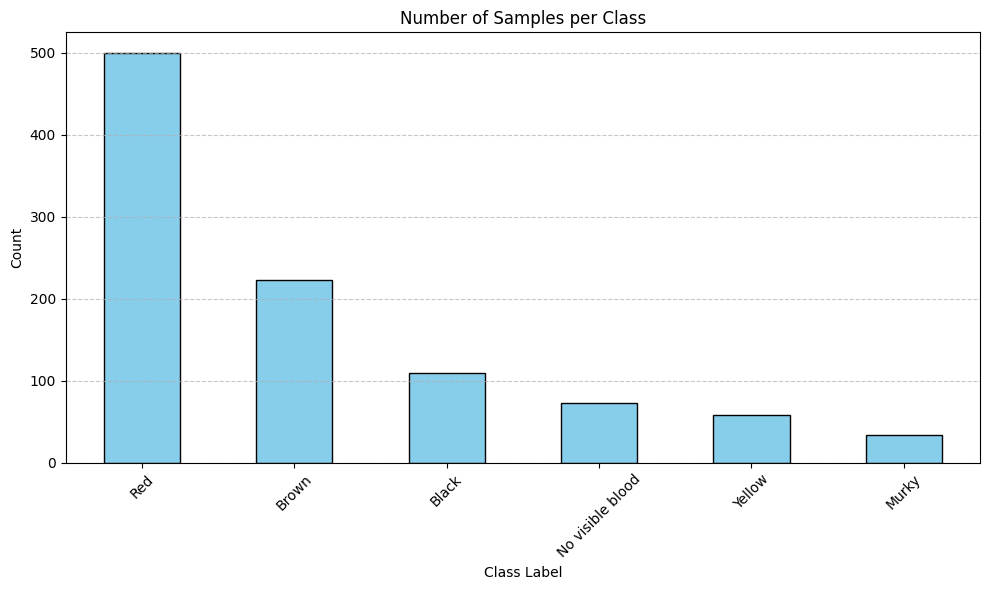

In [3]:
class_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Samples per Class')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# print number of samples per class
print("Number of samples per class:")
print(class_counts)

Number of samples per class:
label
Red                 500
Brown               223
Black               109
No visible blood     73
Yellow               58
Murky                34
Name: count, dtype: int64


In [5]:
images = []
labels = []
for i, row in df.iterrows():
    try:
        img = load_img(row['filepath'], target_size=IMG_SIZE)
        img_array = img_to_array(img).astype(np.float32) / 255.0
        images.append(img_array)
        labels.append(row['label'])
        if (i + 1) % 100 == 0:
            print(f'Loaded {i + 1} images.')
    except Exception as e:
        print(f"Error loading {row['filepath']}: {e}")

images = np.array(images, dtype=np.float32)
labels = np.array(labels)

le = LabelEncoder()
labels_int = le.fit_transform(labels)
num_classes = len(le.classes_)

Loaded 100 images.
Loaded 200 images.
Loaded 300 images.
Loaded 400 images.
Loaded 500 images.
Loaded 600 images.
Loaded 700 images.
Loaded 800 images.
Loaded 900 images.


In [6]:
X_temp, X_test, y_temp, y_test_int = train_test_split(
    images, labels_int, test_size=0.2, random_state=SEED, stratify=labels_int
)
X_train_raw, X_val, y_train_raw, y_val_int = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

X_train_flat = X_train_raw.reshape((X_train_raw.shape[0], -1))
X_train_smote_flat, y_train_int = SMOTE(random_state=SEED).fit_resample(X_train_flat, y_train_raw)
X_train = X_train_smote_flat.reshape((-1, IMG_SIZE[0], IMG_SIZE[1], 3)).astype(np.float32)

y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print('Train set (after SMOTE):', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)

Train set (after SMOTE): (1800, 256, 256, 3) (1800, 6)
Validation set: (200, 256, 256, 3) (200, 6)
Test set: (200, 256, 256, 3) (200, 6)


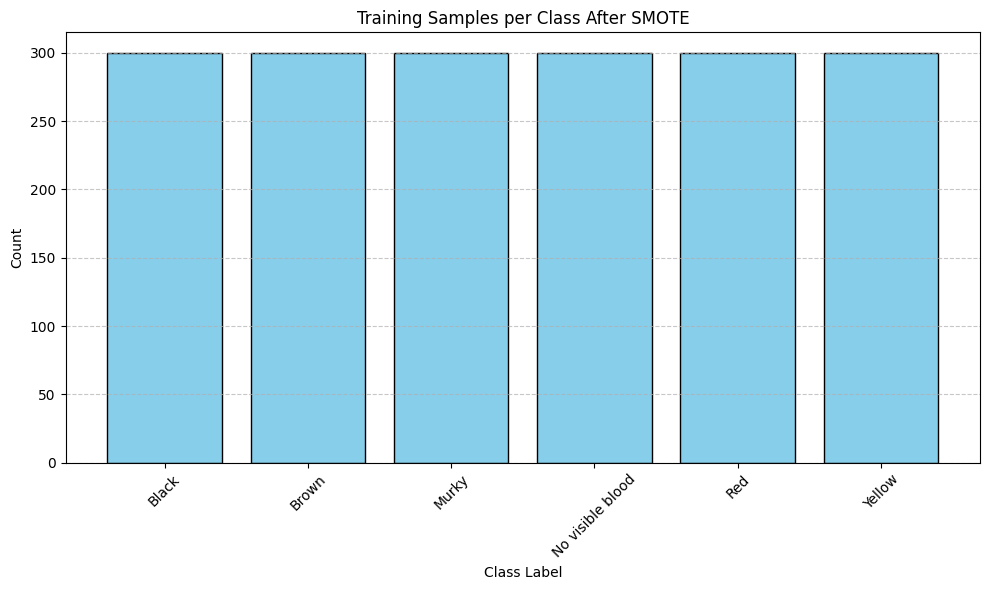

In [7]:
smote_counts = np.bincount(y_train_int, minlength=num_classes)
plt.figure(figsize=(10, 6))
plt.bar(le.classes_, smote_counts, color='skyblue', edgecolor='black')
plt.title('Training Samples per Class After SMOTE')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777094225.970488      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777094225.976400      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,267,398 (50.61 MB)

 Trainable params: 13,267,398 (50.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_path = '/kaggle/working/cnn_smote.h5'
callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-8, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

best_model = tf.keras.models.load_model(model_path)

Epoch 1/30


I0000 00:00:1777094232.416606     126 service.cc:152] XLA service 0x7cef100023f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777094232.416654     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777094232.416663     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777094232.934848     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 05:17:15.825921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 05:17:16.118527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/113 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.2326 - loss: 2.0588

I0000 00:00:1777094239.245564     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2445 - loss: 1.7275
Epoch 1: val_accuracy improved from -inf to 0.52000, saving model to /kaggle/working/cnn_smote.h5


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.3631 - loss: 1.3354 - val_accuracy: 0.5850 - val_loss: 1.1360 - learning_rate: 0.0010
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3815 - loss: 1.2841
Epoch 5: val_accuracy did not improve from 0.58500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3816 - loss: 1.2842 - val_accuracy: 0.5650 - val_loss: 1.4325 - learning_rate: 0.0010
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3620 - loss: 1.3317
Epoch 6: val_accuracy did not improve from 0.58500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3623 - loss: 1.3311 - val_accuracy: 0.5700 - val_loss: 1.1702 - learning_rate: 0.0010
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4580 - loss: 1.2260
Epoch 7: val_accuracy did not improve from 0.58500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.4582 - loss: 1.2257 - val_accuracy: 0.3700 - val_loss: 1.4464 - learning_rate: 0.0010
Epoch 8/30
113/113

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.4947 - loss: 1.1209 - val_accuracy: 0.6000 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5628 - loss: 0.9987
Epoch 9: val_accuracy did not improve from 0.60000

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5633 - loss: 0.9980 - val_accuracy: 0.6000 - val_loss: 1.3386 - learning_rate: 0.0010
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7172 - loss: 0.7382
Epoch 10: val_accuracy improved from 0.60000 to 0.63500, saving model to /kaggle/working/cnn_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7175 - loss: 0.7376 - val_accuracy: 0.6350 - val_loss: 1.5334 - learning_rate: 2.0000e-04
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8143 - loss: 0.5690
Epoch 11: val_accuracy did not improve from 0.63500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8143 - loss: 0.5687 - val_accuracy: 0.6300 - val_loss: 1.6789 - learning_rate: 2.0000e-04
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8383 - loss: 0.5091
Epoch 12: val_accuracy improved from 0.63500 to 0.64000, saving model to /kaggle/working/cnn_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8385 - loss: 0.5086 - val_accuracy: 0.6400 - val_loss: 1.7087 - learning_rate: 2.0000e-04
Epoch 13/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8590 - loss: 0.4053
Epoch 13: val_accuracy did not improve from 0.64000
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8590 - loss: 0.4050 - val_accuracy: 0.6300 - val_loss: 1.7704 - learning_rate: 2.0000e-04
Epoch 14/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8908 - loss: 0.3701
Epoch 14: val_accuracy did not improve from 0.64000

Epoch 14: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8908 - loss: 0.3698 - val_accuracy: 0.6250 - val_loss: 1.8321 - learning_rate: 2.0000e-04
Epoch 15/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9059 - loss: 0.3087
Epoch 15: val_accuracy did not improve from 0.64000
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9060 - 

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9168 - loss: 0.2483 - val_accuracy: 0.6450 - val_loss: 1.9341 - learning_rate: 4.0000e-05
Epoch 19/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9220 - loss: 0.2597
Epoch 19: val_accuracy did not improve from 0.64500

Epoch 19: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9220 - loss: 0.2596 - val_accuracy: 0.6250 - val_loss: 1.8538 - learning_rate: 4.0000e-05
Epoch 20/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9128 - loss: 0.2463
Epoch 20: val_accuracy did not improve from 0.64500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9129 - loss: 0.2461 - val_accuracy: 0.6350 - val_loss: 1.8941 - learning_rate: 8.0000e-06
Epoch 21/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9219 - loss: 0.2308
Epoch 21: val_accuracy did not improve from 0.64500
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9219 - l

In [10]:
def evaluate_split(name, x, y_onehot):
    y_true = np.argmax(y_onehot, axis=1)
    y_pred = np.argmax(best_model.predict(x, batch_size=BATCH_SIZE, verbose=0), axis=1)
    acc = np.mean(y_true == y_pred)
    print(f'{name} Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_true, y_pred

y_train_true, y_train_pred = evaluate_split('Train', X_train, y_train)
y_val_true, y_val_pred = evaluate_split('Validation', X_val, y_val)
y_test_true, y_test_pred = evaluate_split('Test', X_test, y_test)

Train Accuracy: 0.9639
                  precision    recall  f1-score   support

           Black       0.93      0.98      0.96       300
           Brown       0.96      0.96      0.96       300
           Murky       0.96      1.00      0.98       300
No visible blood       0.97      0.96      0.97       300
             Red       0.98      0.89      0.93       300
          Yellow       0.99      0.99      0.99       300

        accuracy                           0.96      1800
       macro avg       0.96      0.96      0.96      1800
    weighted avg       0.96      0.96      0.96      1800

Validation Accuracy: 0.6450
                  precision    recall  f1-score   support

           Black       0.36      0.45      0.40        22
           Brown       0.57      0.60      0.59        45
           Murky       0.40      0.29      0.33         7
No visible blood       0.69      0.79      0.73        14
             Red       0.82      0.74      0.78       100
          Yellow 

In [11]:
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1800
Validation set size: 200
Test set size: 200


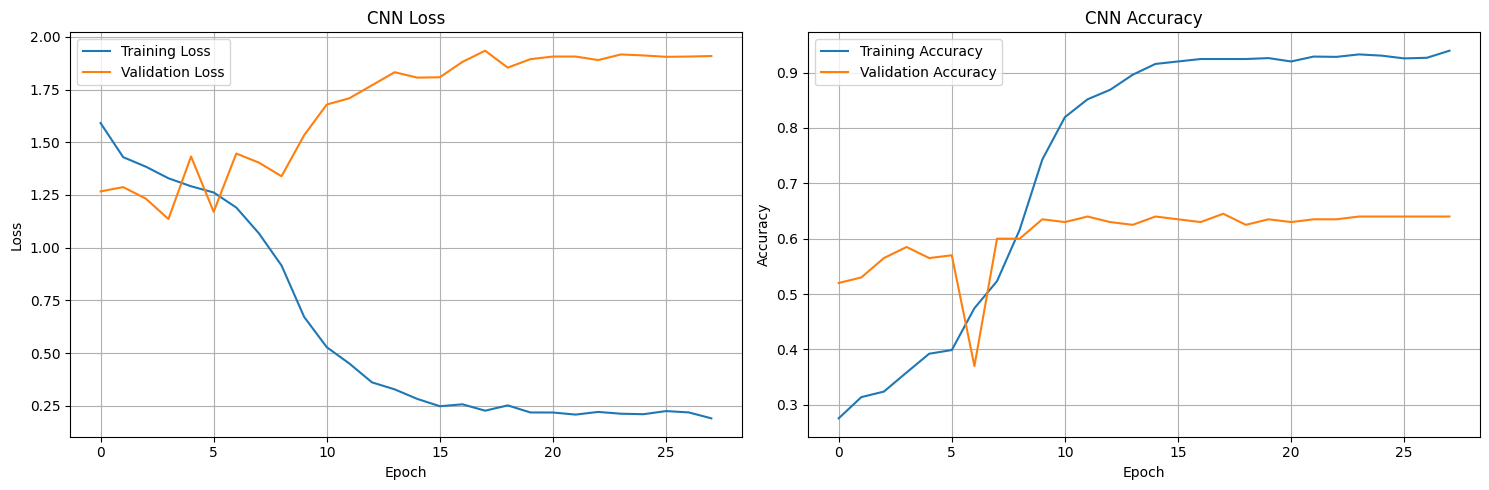

In [12]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

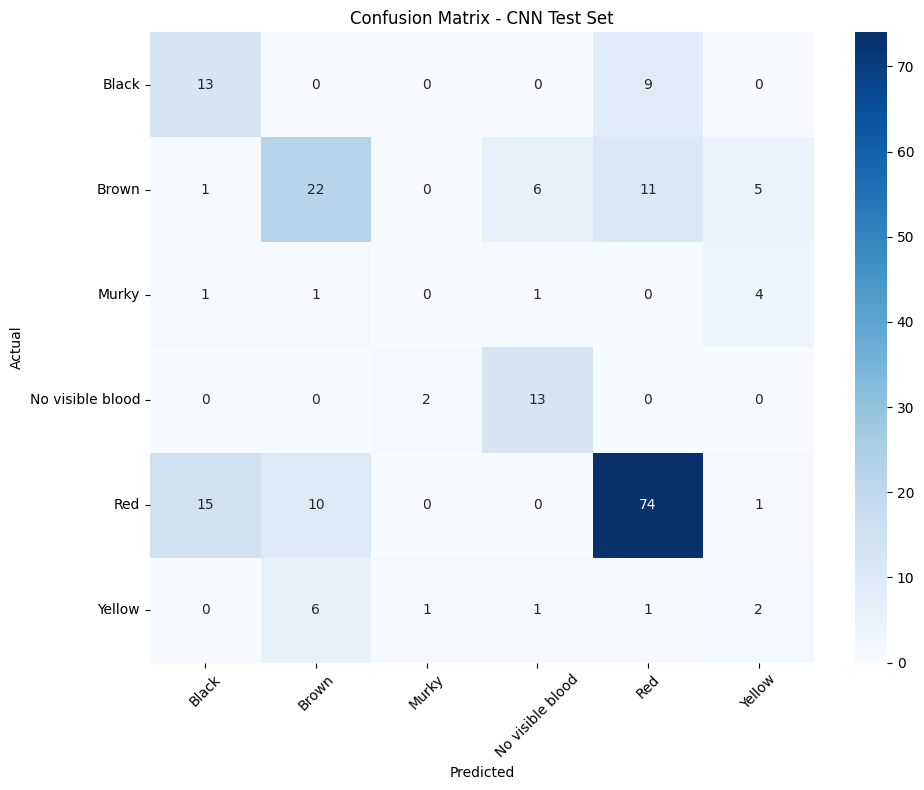

In [13]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - CNN Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()